<a href="https://colab.research.google.com/github/Laurasgrv-colab/PRe/blob/main/image_deblurring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Case Study - image deblurring

sources - https://github.com/paulaoak/proximal-ipla/blob/main/image_deblurring/image_deblurring_experiment_dr_1.ipynb and https://github.com/akyildiz-group/SOSMC

In [ ]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from image_deblurring.algorithms_deblurring import *
import numpy as np
import scipy.ndimage
import imageio.v3 as imageio
import matplotlib.pyplot as plt
import cv2
import pickle

# Load original image



In [8]:
# Load the original image
image = imageio.imread(os.path.join(project_root, 'image_deblurring/photos/original.jpg'), mode="L")
image = image.astype(np.float64)


# Reshape the image for computational cost reasons
n1, n2 = 584, 238
image = scipy.ndimage.zoom(image, (n1 / image.shape[0], n2 / image.shape[1]), order=1)

In [9]:
# Save the reshaped image
path_original_reshaped = os.path.join(project_root, 'image_deblurring/photos/original_reshaped.jpg')
cv2.imwrite(path_original_reshaped, image)

True

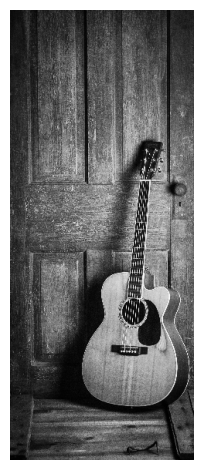

In [10]:
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

# Generate blurred image

In [ ]:
# Generate blurring matrix
H = generate_blur_matrix(n1, n2, 10)

# Generate observed image (y = Hx + noise)
sigma = 0.47
y = H @ image.flatten() + np.random.normal(0, sigma, size=(n1 * n2))
y = y.reshape(n1, n2)

In [ ]:
# Save the blurred observed image
path_blurred = os.path.join(project_root, 'image_deblurring/photos/blurred.jpg')
cv2.imwrite(path_blurred, y)

In [ ]:
plt.imshow(y, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

# Auxiliary functions

In [ ]:
# Compute discrete gradient operator
Dx, Dy = discrete_gradient(n1, n2)

N = 10
sigma_init = 10
w_init = np.random.normal(50, sigma_init, size=(n1, n2, N))
method_tv = "dr"  # dr or chambolle-pock

theta_initial = np.random.uniform(-15, 10, size = 1)[0]

In [ ]:
theta_initial

# SOUL with Metropolis-Hastings

In [ ]:
samples_soul_mh, nmse_soul_mh, thetas_soul_mh, mse_soul_mh, ssim_soul_mh = soul_mh(theta_initial, w_init, H, y, sigma, lambdaaa = 0.001, Dx = Dx, Dy = Dy, original = image, K=3000, h=0.01, method_tv=method_tv)